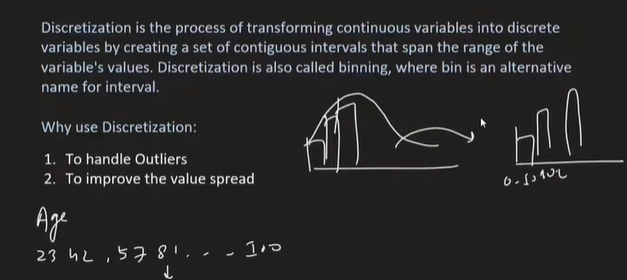

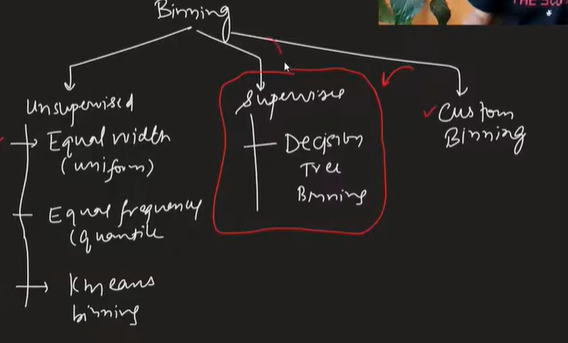

3. K-Means binning:
a clustering algorithm
used when data is in clusters(image shown)
assume we need 5 intervals(centroid)
1.take random posn of 5 centroid
2. draw lines bisecting each interval
3. now the centroid is shifted to the mean of the data of that interval
process repeated.

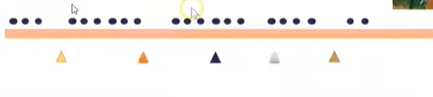

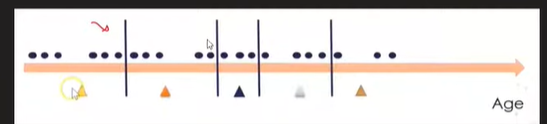

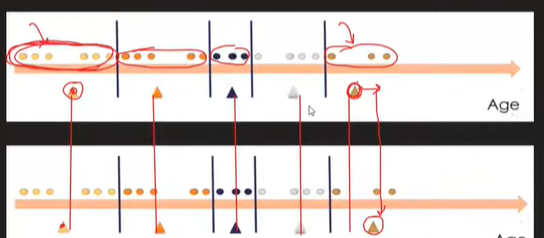

In [3]:
#Titanic w and w/o binning

In [4]:
import numpy as np
import pandas as pd

In [5]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [6]:
df.sample(5)

,Survived,Age,Fare
224,1,38.0,90.0000
92,0,46.0,61.1750
556,1,48.0,39.6000
7,0,2.0,21.0750
471,0,38.0,8.6625


In [7]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [8]:
# Age has missing values
#drop those values
df.dropna(inplace=True)

In [9]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df[['Age','Fare']],df['Survived'],test_size=0.2,random_state=42)

In [11]:
from sklearn.tree import DecisionTreeClassifier

In [12]:
clf=DecisionTreeClassifier()

In [13]:
clf.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
y_predict=clf.predict(x_test)

In [15]:
from sklearn.metrics import accuracy_score

In [16]:
accuracy_score(y_test,y_predict)

0.6223776223776224

In [17]:
from sklearn.preprocessing import KBinsDiscretizer

In [18]:
kbin_age=KBinsDiscretizer(n_bins=20,encode='ordinal',strategy='quantile')
kbin_fare=KBinsDiscretizer(n_bins=20,encode='ordinal',strategy='quantile')

In [19]:
from sklearn.compose import ColumnTransformer

In [20]:
trf=ColumnTransformer(transformers=[
    ('trf1',kbin_age,['Age']),
    ('trf2',kbin_fare,['Fare'])],
    remainder= 'passthrough'
)

In [21]:
trf

,transformers,"[('trf1', ...), ('trf2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,n_bins,20
,encode,'ordinal'
,strategy,'quantile'


In [22]:
x_train_transformed=trf.fit_transform(x_train)
x_test_transformed=trf.transform(x_test)

C:\Users\Dell\Downloads\anaconda\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\Dell\Downloads\anaconda\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [23]:
trf.named_transformers_['trf1'].bin_edges_

array([array([ 0.42,  4.  , 14.  , 18.  , 19.  , 21.  , 22.  , 24.  , 25.  ,
              27.  , 28.5 , 30.  , 32.  , 34.  , 36.  , 39.  , 42.  , 45.5 ,
              50.  , 57.5 , 80.  ])                                         ],
      dtype=object)

In [24]:
trf.named_transformers_['trf2'].bin_edges_

array([array([  0.     ,   7.2292 ,   7.75   ,   7.8542 ,   7.8958 ,   8.05   ,
                9.225  ,  10.5    ,  13.     ,  13.45835,  15.75   ,  20.23125,
               26.     ,  26.41875,  29.125  ,  34.375  ,  51.4792 ,  67.95   ,
               82.1708 , 134.075  , 512.3292 ])                                ],
      dtype=object)

In [25]:
# it is an array, convert to dataframe
pd.DataFrame(x_train_transformed, columns=x_train.columns)
# shows data in in which bin

,Age,Fare
0,11.0,11.0
1,8.0,9.0
2,11.0,10.0
3,12.0,2.0
4,8.0,8.0
...,...,...
566,17.0,16.0
567,8.0,8.0
568,15.0,19.0
569,12.0,11.0


In [26]:
clf.fit(x_train_transformed,y_train)
y_pred1=clf.predict(x_test_transformed)

In [27]:
accuracy_score(y_test,y_pred1)

0.5874125874125874